uni_section_v10: command_v10.md 반영 (synod-20260710-103702-cee330 review / synod-20260710-105249-9ab67a design)
  - §1 T_MAX 2.5mm, DELTA_SCALE 1.35, bias 0.03 (두께 인플레이션 차단 + 재보정)
  - §2 collision v5: surface-gap 제곱 소프트컨택, t detach 금지, alpha 삭제, 전쌍 검사, 부호 앵커
  - §3 2D mesh order loss (w_order=1.0 상시) — v8 붕괴(criss-crossing) 근본 대책
  - §4 2단계 두께 학습: sigmoid gate@128 + thickness 그룹 국소 optimizer 리셋 + lr 0.3x
  - §5 비대칭 Huber phys loss (delta=0.05, undershoot 2.0x)

데이터: nodes=torch.Size([93, 8]) | edges=torch.Size([2, 176])
[gradcheck] dMp/dt OK -- autograd=1.3173e+07, FD=1.3160e+07, rel_err=9.88e-04, dMp/dt>0 확인
[mass] target_area = 1157.3 mm² (초기 단면적 스냅샷)
[collision v5] 전쌍(9쌍) 부호 앵커 & clearance (초기 형상 기준):
    sec0 Part0-Part1: 0seg/1pt σ=+1 clr=-0.05 | 1seg/0pt σ=-1 clr=-0.05
    sec0 Part0-Part2: 0seg/2pt σ=+1 clr=0.50
    sec0 Part0-Part3: 0seg/3pt σ=+1 clr=0.50 | 3seg/0pt σ=-1 clr=0.50
    sec0 Part0-Part4: 0seg/4pt σ=+1 clr=0.50 | 4seg/0pt σ=-1 clr=0.50
    sec0 Part1-Part2: 1seg/2pt

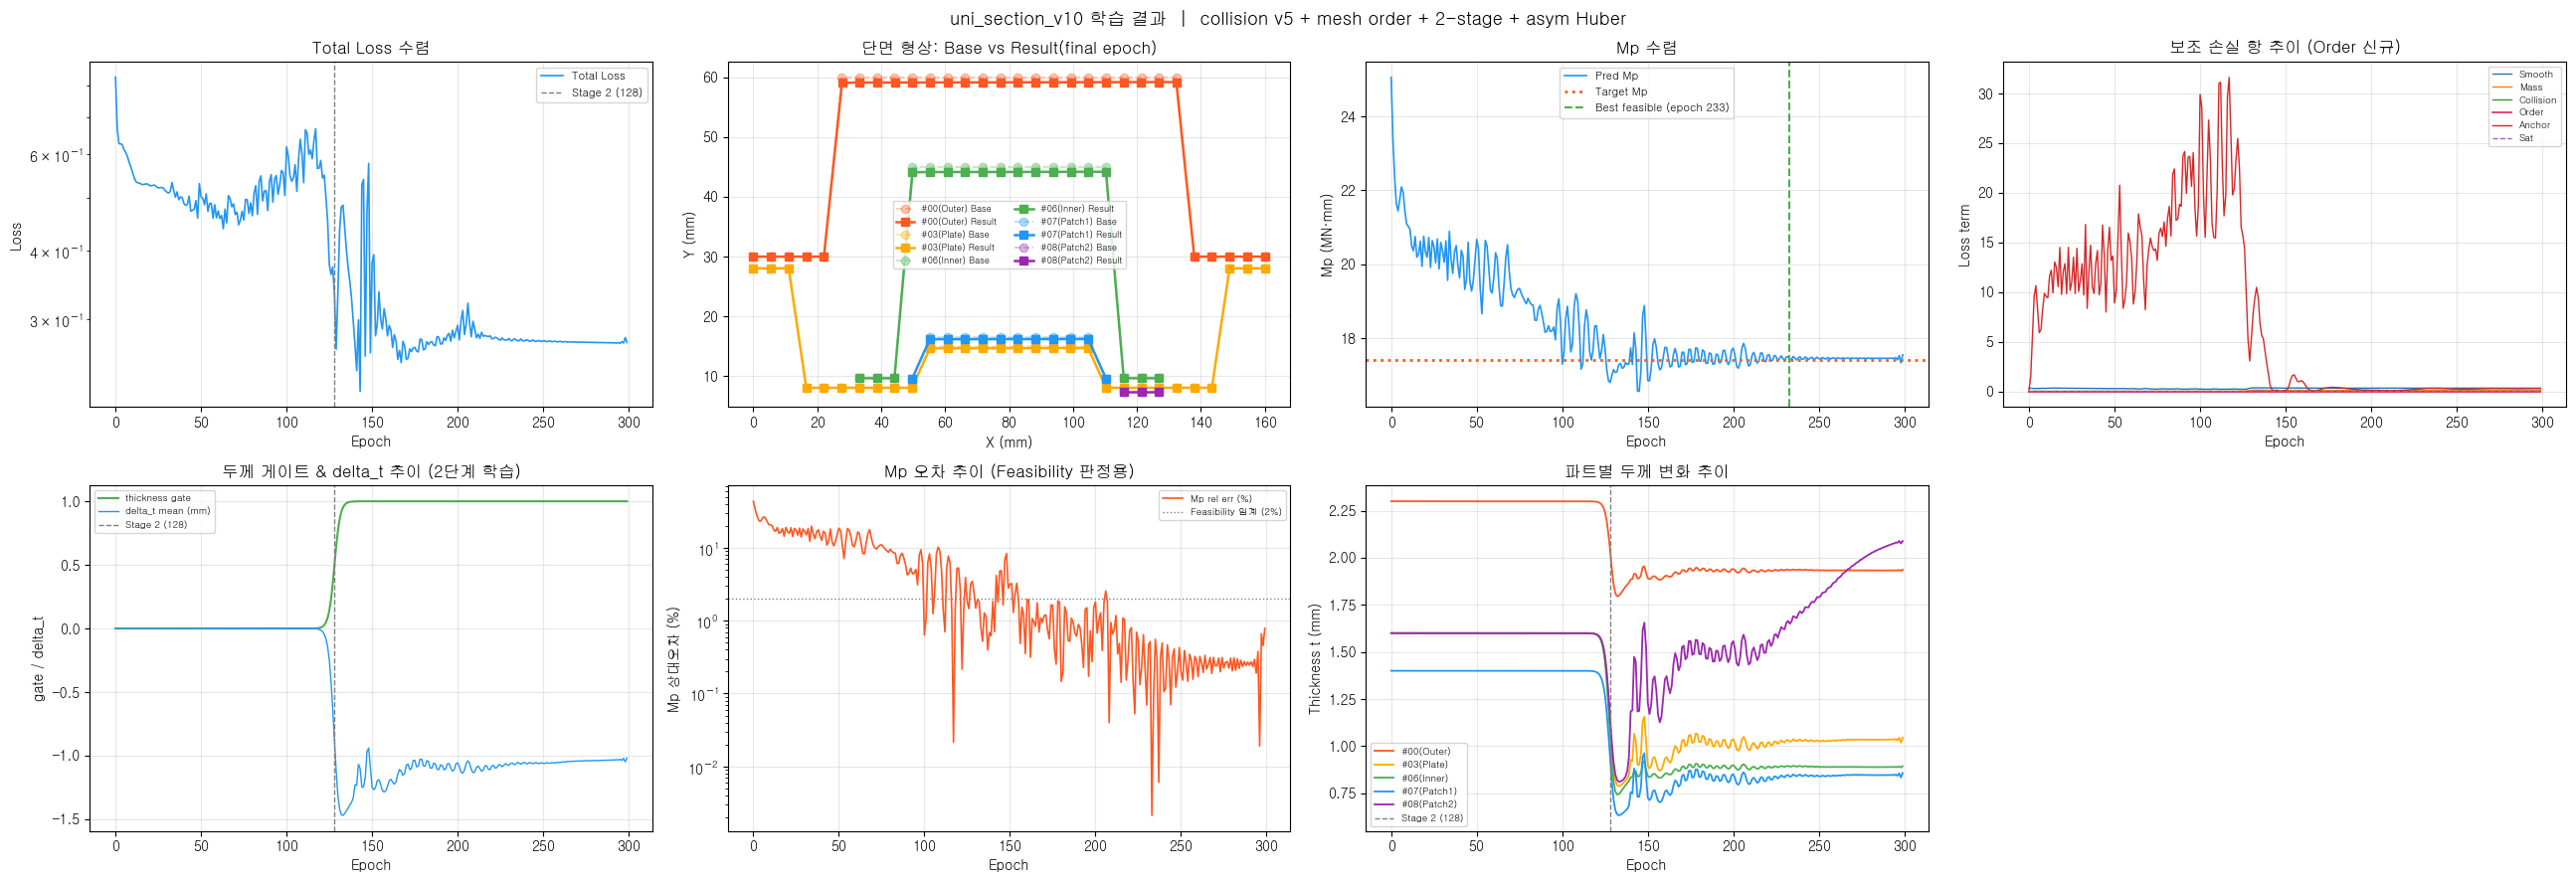


결과 저장: c:\Users\user\Documents\GitHub\hmc_mlv\CGNN\uni-section\uni_section_v10_result.png

최종 결과 요약 (마지막 epoch 기준)
  Target Mp     :     17,421,470 N·mm
  Final pred_mp :     17,558,628 N·mm
  Final Error   :   0.79%
  Final l_collision : 0.0000
  Final l_order : 0.0000
  Final delta_t : mean=-1.018 mm

  ★ Feasible 모델(물리 제약 + Mp 동시 만족) 발견: epoch 233, Mp err=0.00%, l_collision=0.0000
    (best_feasible['state_dict']를 model.load_state_dict()로 복원해 사용 권장)


In [6]:
#!/usr/bin/env python
# coding: utf-8

"""
uni_section_v10.py
─────────────────────────────────────
uni_section_v8.py를 docs/command_v10.md 지시 사항에 따라 재작성한 버전.
설계 근거: /synod review 세션 synod-20260710-103702-cee330 (v9 제안 5건 판정)
구현 결정: /synod design 세션 synod-20260710-105249-9ab67a (D1~D5, 조기 합의)

command_v10.md 반영 사항:
  §1 T_MAX 4.0→2.5mm, DELTA_SCALE 1.5→1.35, thickness bias 0.07→0.03 (재보정 동반)
  §2 Collision v5 (최우선):
     - v8 segment 법선 투영 유지, projection → surface gap 변환:
         gap = sigma_pair × projection - (t_a + t_b)/2 - clearance_pair
     - 두께 t는 detach 금지 (두께↑ → gap↓ → 밀어내기 gradient 경로가 핵심 메커니즘)
     - violation = relu(-gap).clamp(max=1.0)  → mean(violation²) 제곱 소프트컨택
     - Ghost Gate alpha 완전 삭제 (두께가 gap에 내재화되어 수학적 중복)
     - 인접쌍 → 전체 unordered 쌍 (i<j, 10쌍) 검사
     - pair_margins 딕셔너리 폐지 → CLEARANCE=0.5 단일 상수,
       초기 gap 여유가 부족한 쌍만 쌍별 국소 완화 (출발부터 위반 방지)
     - [D2] 부호 앵커: 초기 형상에서 파트쌍·방향별 투영 부호(sigma)를 고정 버퍼로 저장
       → 임의 쌍에서도 signed gap이 강건, 깊은 관통도 감지 (false-negative 방지)
  §3 Mesh Order Loss (신규, v8 붕괴 근본 대책):
     - 파트 내부 엣지의 초기 방향 단위벡터 ê0에 대한 투영 proj = e_new·ê0
     - violation = relu(0.5 - proj), mean squared, w_order=1.0 상시 활성
     - 1D dx-sign(v9 원안)은 수직 세그먼트에서 오작동 → 2D 내적으로 일반화
  §4 두께 2단계 학습:
     - thickness gate = sigmoid(0.6×(epoch-128)) — epoch ~120까지 사실상 동결
     - Stage 2 진입(epoch 128)시 thickness_decoder 파라미터 그룹만 AdamW state 국소
       리셋 + 해당 그룹 lr 0.3× (좌표 헤드 모멘텀은 보존) [D4]
     - Stage 1 동안 w_mass 실효 0 (gate 연동) [D3]
  §5 비대칭 Huber phys loss (v8 sqrt 대체):
     - delta=0.05, undershoot 가중 2.0× (v9 원안 5×err²는 기각)
     - err→0에서 gradient 발산 없음(quadratic 구간) + 큰 오차에서 폭발 없음(linear 구간)
  §6 가중치: w_phys=10, w_collision=5, w_order=1(신규), w_mass=2(게이트),
     w_smooth=0.5, w_anchor=0.02, w_sat=0.01 | 300 epochs, AdamW 1e-3, clip 5.0

v8과 동일하게 유지되는 부분:
  - CGDN(GATv2+FiLM) 백본, build_bpillar_section() 초기 좌표·fix point·엣지 구성
  - §3.1 native autograd Mp (Envelope Theorem) + verify_thickness_gradient 게이트
  - 커리큘럼(s_phys 0.2→1.0 sine ramp, s_smooth ramp) — [D3 Judge 판정: 유지]
  - dual-threshold feasibility + best-Mp 체크포인트
"""

import math
import os
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import matplotlib.pyplot as plt
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['font.family'] = 'Gulim'  # Windows 한글 폰트

from torch_geometric.nn import GATv2Conv, LayerNorm
from torch_geometric.data import Data


# ══════════════════════════════════════════════════════════════════
# SECTION 0: Mp 계산 — native autograd (v8 §3.1 유지)
# ══════════════════════════════════════════════════════════════════

def compute_edge_mp_pna(coords, t, fy, edge_index, n_iter=50):
    """
    Thick Edge (2D Plate) PNA 이분탐색 + Mp 계산 (v8 그대로).
    y_pna는 no_grad(Envelope Theorem 적용점), Mp는 미분 가능 연산.
    Returns: (mp_total, y_pna)
    """
    mask = edge_index[0] < edge_index[1]
    u, v = edge_index[0][mask], edge_index[1][mask]

    y_u, y_v = coords[u, 1], coords[v, 1]
    x_u, x_v = coords[u, 0], coords[v, 0]
    L = torch.sqrt((x_u - x_v) ** 2 + (y_u - y_v) ** 2)
    t_e  = t[u].squeeze(-1)
    fy_e = fy[u].squeeze(-1)

    dx   = torch.abs(x_u - x_v)
    t_y  = t_e * (dx / (L + 1e-12))
    y_max = torch.maximum(y_u, y_v)
    y_min = torch.minimum(y_u, y_v)
    y_top = y_max + t_y / 2.0
    y_bot = y_min - t_y / 2.0
    H     = torch.clamp(y_top - y_bot, min=1e-12)

    Area_fy = L * t_e * fy_e

    with torch.no_grad():
        y_lo = coords[:, 1].min().clone() - 5.0
        y_hi = coords[:, 1].max().clone() + 5.0
        for _ in range(n_iter):
            y_mid = 0.5 * (y_lo + y_hi)
            alpha = torch.clamp((y_top - y_mid) / H, 0.0, 1.0)
            net_force = torch.sum(Area_fy * (2.0 * alpha - 1.0))
            if net_force > 0:
                y_lo = y_mid
            else:
                y_hi = y_mid
        y_pna = 0.5 * (y_lo + y_hi)

    alpha        = torch.clamp((y_top - y_pna) / H, 0.0, 1.0)
    centroid_top = y_top - (alpha * H) / 2.0
    centroid_bot = y_bot + ((1.0 - alpha) * H) / 2.0
    m_top        = alpha * (centroid_top - y_pna)
    m_bot        = (1.0 - alpha) * (y_pna - centroid_bot)
    mp_total     = torch.sum(Area_fy * (m_top + m_bot))

    return mp_total, y_pna


def calculate_mpl(coords, t, fy, edge_index):
    mp_total, _ = compute_edge_mp_pna(coords, t, fy, edge_index)
    return mp_total


def verify_thickness_gradient(coords, t, fy, edge_index, eps=1e-4):
    """[v8 §3.1 유지] 학습 전 유한차분으로 ∂Mp/∂t 검증 — 실패 시 학습 중단."""
    coords = coords.detach()
    fy = fy.detach()

    t_leaf = t.detach().clone().requires_grad_(True)
    mp, _ = compute_edge_mp_pna(coords, t_leaf, fy, edge_index)
    mp.backward()
    if t_leaf.grad is None:
        raise RuntimeError("[gradcheck] dMp/dt 가 None!")
    grad_sum = t_leaf.grad.sum().item()

    with torch.no_grad():
        mp_p, _ = compute_edge_mp_pna(coords, t + eps, fy, edge_index)
        mp_m, _ = compute_edge_mp_pna(coords, t - eps, fy, edge_index)
    fd = (mp_p.item() - mp_m.item()) / (2.0 * eps)

    rel_err = abs(fd - grad_sum) / (abs(fd) + 1e-8)
    if fd <= 0:
        raise RuntimeError(f"[gradcheck] dMp/dt = {fd:.4e} <= 0 -- 물리적으로 비정상!")
    if rel_err > 1e-3:
        raise RuntimeError(f"[gradcheck] autograd({grad_sum:.6e}) vs FD({fd:.6e}) "
                           f"상대오차 {rel_err:.2e} > 1e-3")
    print(f"[gradcheck] dMp/dt OK -- autograd={grad_sum:.4e}, FD={fd:.4e}, "
          f"rel_err={rel_err:.2e}, dMp/dt>0 확인")
    return grad_sum, fd, rel_err


class FiLMGenerator(nn.Module):
    """target_mp [B, 1] → (gamma, beta) [B, hidden] (v8 그대로)"""
    MP_SCALE = 1e6

    def __init__(self, hidden_channels: int):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, 64),
            nn.GELU(),
            nn.Linear(64, hidden_channels * 2),
        )
        nn.init.zeros_(self.net[-1].weight)
        nn.init.zeros_(self.net[-1].bias)

    def forward(self, target_mp):
        target_mp_norm = target_mp / self.MP_SCALE
        out = self.net(target_mp_norm)
        delta_gamma, beta = torch.chunk(out, 2, dim=-1)
        gamma = 1.0 + delta_gamma
        return gamma, beta


class CGDNBlock(nn.Module):
    """GATv2Conv → LayerNorm → FiLM → GELU → Residual (v8 그대로)"""
    def __init__(self, hidden_channels: int, heads: int = 4, edge_dim: int = 4):
        super().__init__()
        assert hidden_channels % heads == 0
        self.conv = GATv2Conv(
            hidden_channels,
            hidden_channels // heads,
            heads=heads,
            edge_dim=edge_dim,
            concat=True,
        )
        self.norm = LayerNorm(hidden_channels)

    def forward(self, h, edge_index, edge_attr, gamma, beta):
        h_res = h
        h = self.conv(h, edge_index, edge_attr)
        h = self.norm(h)
        h = gamma * h + beta
        h = F.gelu(h)
        h = h + h_res
        return h


class CGDN(nn.Module):
    """
    Constraint-aware Graph Deformation Network v10
    [command_v10.md §1] T_MAX 2.5 / DELTA_SCALE 1.35 / bias 0.03
    [command_v10.md §2.3] Ghost Gate alpha 삭제
    [command_v10.md §4] forward(thickness_gate=...) — 2단계 두께 학습 게이트

    forward() 반환값: (new_coords, delta_coords, t_final, delta_t_part)
    """

    DELTA_SCALE = 1.35   # [§1] 1.5 → 1.35 (T_MAX 축소에 비례 완화)
    T_MIN       = 0.1    # mm
    T_MAX       = 2.5    # mm — [§1] 핫스탬핑 상용 두께 한계 (두께 인플레이션 차단)

    def __init__(
        self,
        in_channels: int = 8,
        hidden_channels: int = 128,
        num_layers: int = 4,
        heads: int = 4,
        edge_dim: int = 4,
        max_displacement: float = 50.0,
    ):
        super().__init__()
        self.max_displacement = max_displacement
        self.num_layers = num_layers

        self.node_encoder = nn.Sequential(
            nn.Linear(in_channels, hidden_channels),
            LayerNorm(hidden_channels),
            nn.GELU(),
        )
        self.film_generators = nn.ModuleList([
            FiLMGenerator(hidden_channels) for _ in range(num_layers)
        ])
        self.blocks = nn.ModuleList([
            CGDNBlock(hidden_channels, heads=heads, edge_dim=edge_dim)
            for _ in range(num_layers)
        ])

        self.coord_decoder = nn.Sequential(
            nn.Linear(hidden_channels, 64),
            nn.GELU(),
            nn.Linear(64, 2),
        )

        self.thickness_decoder = nn.Sequential(
            nn.Linear(hidden_channels, 32),
            nn.GELU(),
            nn.Linear(32, 1),
        )
        nn.init.constant_(self.thickness_decoder[-1].bias, 0.03)  # [§1] 0.07 → 0.03

    @staticmethod
    def leaky_tanh(x):
        """0.95·tanh(x) + 0.05·x/3 — gradient 하한 확보 (v8 §3.4 유지)"""
        return 0.95 * torch.tanh(x) + 0.05 * x / 3.0

    def forward(self, x, edge_index, edge_attr, target_mp,
                fix_x_mask, fix_y_mask, join_pairs=None, thickness_gate=1.0):
        h = self.node_encoder(x)

        for i, block in enumerate(self.blocks):
            gamma, beta = self.film_generators[i](target_mp)
            h = block(h, edge_index, edge_attr, gamma, beta)

        # ── 좌표 예측 ──
        delta_coords = self.coord_decoder(h)
        delta_coords = torch.clamp(delta_coords, -self.max_displacement, self.max_displacement)
        delta_x = delta_coords[:, 0:1] * (~fix_x_mask).float()
        delta_y = delta_coords[:, 1:2] * (~fix_y_mask).float()
        delta_coords = torch.cat([delta_x, delta_y], dim=1)
        new_coords = x[:, :2] + delta_coords

        if join_pairs is not None and join_pairs.shape[0] > 0:
            u_idx = join_pairs[:, 0]
            v_idx = join_pairs[:, 1]
            mid = (new_coords[u_idx] + new_coords[v_idx]) * 0.5
            new_coords = new_coords.clone()
            new_coords[u_idx] = mid
            new_coords[v_idx] = mid

        # ── 두께 예측 ──
        delta_t_raw = self.thickness_decoder(h)
        delta_t_raw = self.leaky_tanh(delta_t_raw) * self.DELTA_SCALE

        # Part-level 단일 두께 강제 (제조 제약)
        part_ids_local    = x[:, 4].long()
        section_ids_local = x[:, 5].long()
        t_initial         = x[:, 6].unsqueeze(1)

        max_parts = int(part_ids_local.max().item()) + 1
        composite_key = section_ids_local * max_parts + part_ids_local
        _, inverse = torch.unique(composite_key, return_inverse=True)
        num_groups = int(inverse.max().item()) + 1

        delta_t_1d  = delta_t_raw.squeeze(-1)
        group_sum   = torch.zeros(num_groups, device=x.device).scatter_add_(0, inverse, delta_t_1d)
        group_count = torch.zeros(num_groups, device=x.device).scatter_add_(0, inverse, torch.ones_like(delta_t_1d))
        group_mean  = group_sum / group_count.clamp(min=1)
        delta_t_part = group_mean[inverse].unsqueeze(-1)

        # [§4] 2단계 학습 게이트: Stage 1(gate≈0)에서 두께 사실상 동결
        delta_t_part = delta_t_part * thickness_gate

        # Soft clamp (logit-sigmoid, T_MAX=2.5)
        t_min, t_max = self.T_MIN, self.T_MAX
        t_initial_frac = (t_initial - t_min) / (t_max - t_min)
        t_initial_frac = torch.clamp(t_initial_frac, 1e-4, 1.0 - 1e-4)
        t_initial_logit = torch.logit(t_initial_frac)
        t_final = t_min + (t_max - t_min) * torch.sigmoid(t_initial_logit + delta_t_part)

        return new_coords, delta_coords, t_final, delta_t_part


# ══════════════════════════════════════════════════════════════════
# SECTION 1: Loss Functions
# ══════════════════════════════════════════════════════════════════

def asymmetric_huber_phys(pred_mp, target_mp, delta=0.05, under_w=2.0):
    """
    [command_v10.md §5] 비대칭 Huber phys loss.
    |err|<=delta: 제곱(수렴 안정, err→0에서 gradient 발산 없음)
    |err|> delta: 선형(gradient 폭발 방지, C1 연속)
    undershoot(err<0)엔 under_w배 — Mp 미달을 더 강하게 처벌하되 5×는 기각(두께 인플레 압력 부활 방지).
    """
    err = (pred_mp - target_mp) / target_mp
    abs_err = err.abs()
    huber = torch.where(abs_err <= delta,
                        0.5 * abs_err ** 2 / delta,
                        abs_err - 0.5 * delta)
    w = torch.where(err < 0,
                    torch.full_like(err, under_w),
                    torch.ones_like(err))
    return w * huber


def compute_smoothness_loss_angle(new_coords, edge_index, edge_attr):
    """노드별 좌우 엣지 각도 최소화 & 90도 미만 제한 (v8 그대로)"""
    src, dst = edge_index
    edge_type = edge_attr[:, 3]

    mask = (src < dst) & torch.isclose(edge_type, torch.zeros_like(edge_type))
    if not mask.any():
        return torch.tensor(0.0, device=new_coords.device)

    src = src[mask]
    dst = dst[mask]

    num_nodes = new_coords.shape[0]
    all_u = torch.cat([src, dst])
    all_v = torch.cat([dst, src])

    adj = [[] for _ in range(num_nodes)]
    for u, v in zip(all_u.tolist(), all_v.tolist()):
        adj[u].append(v)

    left_angles = []
    right_angles = []

    for node, neighbors in enumerate(adj):
        if len(neighbors) < 2:
            continue

        node_x = new_coords[node, 0]
        left_nodes = [n for n in neighbors if new_coords[n, 0] < node_x]
        right_nodes = [n for n in neighbors if new_coords[n, 0] > node_x]

        if len(left_nodes) != 1 or len(right_nodes) != 1:
            continue

        left_node = left_nodes[0]
        right_node = right_nodes[0]

        left_vec = new_coords[node] - new_coords[left_node]
        right_vec = new_coords[right_node] - new_coords[node]

        left_angles.append(torch.atan2(left_vec[1], left_vec[0]))
        right_angles.append(torch.atan2(right_vec[1], right_vec[0]))

    if len(left_angles) == 0:
        return torch.tensor(0.0, device=new_coords.device)

    left_angles = torch.stack(left_angles)
    right_angles = torch.stack(right_angles)

    results = 0.0

    angle_diff = (left_angles - right_angles + math.pi) % (2.0 * math.pi) - math.pi
    results += torch.mean(angle_diff.pow(2))

    max_rad = math.pi / 2.0
    left_violation = torch.relu(left_angles.abs() - max_rad)
    right_violation = torch.relu(right_angles.abs() - max_rad)
    results += torch.mean(left_violation.pow(2) + right_violation.pow(2))

    return results


def compute_mass_loss(new_coords, t, edge_index, edge_attr, target_area):
    """target 기반 mass loss: l_mass = ((A - A0)/A0)^2 (v8 §3.3 유지)"""
    src, dst = edge_index
    edge_type = edge_attr[:, 3]

    mask = (src < dst) & torch.isclose(edge_type, torch.zeros_like(edge_type))
    src = src[mask]
    dst = dst[mask]

    seg_len = torch.norm(new_coords[src] - new_coords[dst], dim=1)
    t_src = t[src].squeeze(-1)
    area = torch.sum(seg_len * t_src)

    l_mass = ((area - target_area) / (target_area + 1e-12)) ** 2
    return area, l_mass


def compute_anchor_loss(new_coords, base_coords, fix_x_mask, fix_y_mask):
    disp = new_coords - base_coords
    return torch.mean(disp[:, 0] ** 2 + disp[:, 1] ** 2)


def compute_saturation_loss(delta_t_part, delta_scale=1.35, knee=0.9):
    """L_sat = relu(|delta_t| - knee×scale)^2 (v8 §3.4 유지, scale 1.35)"""
    threshold = knee * delta_scale
    return torch.mean(torch.relu(delta_t_part.abs() - threshold) ** 2)


def compute_mesh_order_loss(base_coords, new_coords, edge_index, edge_attr, eps=0.5):
    """
    [command_v10.md §3] 2D Mesh Order Loss — v8 붕괴(criss-crossing) 근본 대책.
    파트 내부 엣지의 현재 벡터가 초기 방향 단위벡터 ê0 위로 최소 eps(0.5mm) 이상
    투영되도록 강제 → 방향 반전(교차)과 과도 압축을 동시에 차단.
    1D dx-sign(v9 원안)과 달리 수직 세그먼트에서도 안정적으로 동작.
    """
    src, dst = edge_index
    mask = (src < dst) & (edge_attr[:, 3] == 0.0)
    if not mask.any():
        return torch.tensor(0.0, device=new_coords.device)

    e0 = base_coords[dst[mask]] - base_coords[src[mask]]
    e0_hat = e0 / (e0.norm(dim=1, keepdim=True) + 1e-8)
    e_new = new_coords[dst[mask]] - new_coords[src[mask]]
    proj = (e_new * e0_hat).sum(dim=1)
    violation = torch.relu(eps - proj)
    return torch.mean(violation ** 2)


# ── [command_v10.md §2] Collision v5 ──────────────────────────────

def _signed_projections(coords_seg, coords_pts):
    """
    점→세그먼트 부호 있는 법선 투영 (v8 기하 유지, 부호 규약만 고정).
    normal = (tangent.y, -tangent.x) 단일 규약 — 방향성은 sigma 앵커가 담당.
    Returns: (projection [n_pts, n_segs], valid_mask [n_pts, n_segs])
    """
    A = coords_seg[:-1]
    B = coords_seg[1:]
    AB = B - A

    P = coords_pts.unsqueeze(1)
    A_exp = A.unsqueeze(0)
    AB_exp = AB.unsqueeze(0)

    AB_squared = torch.sum(AB_exp ** 2, dim=-1) + 1e-8
    AP = P - A_exp
    t_proj = torch.sum(AP * AB_exp, dim=-1) / AB_squared
    valid_mask = (t_proj >= 0.0) & (t_proj <= 1.0)

    C = A_exp + t_proj.unsqueeze(-1) * AB_exp
    tangent = AB_exp / (torch.norm(AB_exp, dim=-1, keepdim=True) + 1e-8)
    normal = torch.stack([tangent[..., 1], -tangent[..., 0]], dim=-1)

    CP = P - C
    projection = torch.sum(CP * normal, dim=-1)
    return projection, valid_mask


def build_collision_spec(coords, t, part_ids, section_ids,
                          clearance_default=0.5, init_buffer=0.05, sign_eps=1e-3,
                          degenerate_clearance=-5.0):
    """
    [§2 / D2] 초기 형상에서 전체 unordered 파트쌍 (a<b) × 양방향(a-seg/b-pt, b-seg/a-pt)에
    대해 부호 앵커(sigma)와 쌍별 clearance를 산정해 고정.
      sigma      = sign(mean(valid projection))  (|mean|<eps → +1)
      slack      = min(sigma×proj) - (t_a0+t_b0)/2      (초기 표면 여유)
      clearance  = min(0.5, slack - 0.05)               (출발부터 위반 방지, 음수 허용)
    Returns: {(sec, a, b): [ {roles, sigma, clearance}, ... 2방향 ]}
    """
    spec = {}
    with torch.no_grad():
        for sec in torch.unique(section_ids):
            sec_int = int(sec.item())
            sec_mask = (section_ids == sec)
            parts = sorted(int(p.item()) for p in torch.unique(part_ids[sec_mask]))
            for i in range(len(parts)):
                for j in range(i + 1, len(parts)):
                    a, b = parts[i], parts[j]
                    mask_a = sec_mask & (part_ids == a)
                    mask_b = sec_mask & (part_ids == b)
                    ca, cb = coords[mask_a], coords[mask_b]
                    t_a0 = t[mask_a].mean().item()
                    t_b0 = t[mask_b].mean().item()

                    directions = []
                    for (c_seg, c_pt, roles) in [(ca, cb, (a, b)), (cb, ca, (b, a))]:
                        if c_seg.shape[0] < 2 or c_pt.shape[0] == 0:
                            continue
                        proj, valid = _signed_projections(c_seg, c_pt)
                        if valid.sum() == 0:
                            continue
                        vals = proj[valid]
                        m = vals.mean().item()
                        sigma = 1.0 if abs(m) < sign_eps else float(np.sign(m))
                        slack = (sigma * vals).min().item() - (t_a0 + t_b0) / 2.0
                        clearance = min(clearance_default, slack - init_buffer)
                        # 혼합 부호 기하(점들이 세그먼트 양쪽에 분포)로 clearance가 퇴화한
                        # 방향은 스킵 — 항상 loss 0인 무의미 항이며, 역방향이 해당 쌍을 담당.
                        if clearance < degenerate_clearance:
                            continue
                        directions.append({
                            'seg_part': roles[0], 'pt_part': roles[1],
                            'sigma': sigma, 'clearance': clearance,
                        })
                    if directions:
                        spec[(sec_int, a, b)] = directions
    return spec


def compute_collision_loss_v5(new_coords, t_final, part_ids, section_ids, collision_spec):
    """
    [command_v10.md §2] Collision v5 — 두께 연동 surface-gap + 제곱 소프트컨택.
      gap = sigma × projection - (t_seg_part + t_pt_part)/2 - clearance_pair
      violation = relu(-gap).clamp(max=1.0)   (초기 침투 폭발 방지 하드 클립)
      loss = mean(violation²)  (선형 sum → 제곱 mean: 절벽 gradient·핑퐁 진동 제거)
    두께 t_final은 detach하지 않음 — "두께↑ → margin↑ → 밀어내기"의 gradient 경로.
    alpha(Ghost Gate) 없음. 전체 쌍 검사.
    """
    total_loss = torch.tensor(0.0, device=new_coords.device, requires_grad=True)
    n_dirs = 0

    for (sec_int, a, b), directions in collision_spec.items():
        sec_mask = (section_ids == sec_int)
        part_coords = {
            a: new_coords[sec_mask & (part_ids == a)],
            b: new_coords[sec_mask & (part_ids == b)],
        }
        # [D1] 파트 균일 두께 → 스칼라(mean은 항등, 미분 가능)
        part_t = {
            a: t_final[sec_mask & (part_ids == a)].mean(),
            b: t_final[sec_mask & (part_ids == b)].mean(),
        }

        for d in directions:
            c_seg = part_coords[d['seg_part']]
            c_pt  = part_coords[d['pt_part']]
            if c_seg.shape[0] < 2 or c_pt.shape[0] == 0:
                continue
            proj, valid = _signed_projections(c_seg, c_pt)
            if valid.sum() == 0:
                continue

            t_sum_half = (part_t[d['seg_part']] + part_t[d['pt_part']]) / 2.0
            gap = d['sigma'] * proj - t_sum_half - d['clearance']
            violation = torch.relu(-gap).clamp(max=1.0) * valid.float()
            loss_dir = (violation ** 2).sum() / valid.float().sum()
            total_loss = total_loss + loss_dir
            n_dirs += 1

    if n_dirs > 0:
        total_loss = total_loss / n_dirs
    return total_loss


# ══════════════════════════════════════════════════════════════════
# SECTION 2: 커리큘럼 & 2단계 두께 게이트
# ══════════════════════════════════════════════════════════════════

STAGE2_EPOCH = 128        # [§4] 두께 게이트 중심점 (epoch ~120까지 gate≈0)
GATE_STEEPNESS = 0.6      # sigmoid 기울기 — 약 15 epoch 램프


def thickness_gate_value(epoch):
    """[§4] gate = sigmoid(0.6×(epoch-128)) — Stage 1 동결, ~15 epoch 소프트 램프"""
    return float(torch.sigmoid(torch.tensor(GATE_STEEPNESS * (epoch - STAGE2_EPOCH))).item())


def get_curriculum_weights_v10(epoch, total_epochs, curriculum_ratio):
    """
    v8 3-stage curriculum 유지 [D3 Judge 판정] — 단 s_mass는 두께 게이트가 대체.
      s_collision = 1.0 상시, s_order = 1.0 상시(신규, collision과 동급 하드 제약)
      s_phys: 0.2→1.0 sine ramp, s_smooth: 0→1 ramp
    """
    stage_a_end = int(total_epochs * curriculum_ratio[0])
    stage_b_end = int(total_epochs * curriculum_ratio[1])

    if epoch < stage_a_end:
        progress = 0.0
    elif epoch < stage_b_end:
        x = (epoch - stage_a_end) / max(stage_b_end - stage_a_end, 1)
        progress = 0.5 * (1 + math.sin(math.pi * (x - 0.5)))
    else:
        progress = 1.0

    s_phys   = 0.2 + 0.8 * progress
    s_smooth = progress
    return s_phys, s_smooth


# ══════════════════════════════════════════════════════════════════
# SECTION 3: Data Setup (build_bpillar_section — v8 그대로, 수정 없음)
# ══════════════════════════════════════════════════════════════════

def build_bpillar_section():
    """B-Pillar 5-Part 단면 (v8/validate_v9와 100% 동일)"""
    part_configs = [
        (0, 30.0, 2.30, 1470.0, True),   # #00 Outer Hat
        (1, 28.05, 1.60,  980.0, False), # #03 Inner Plate
        (2, 29.0, 1.60, 1470.0, True),   # #06 Inner Hat
        (3, 24.0, 1.40,  980.0, False),  # #07 Patch 1
        (4, 22.0, 1.60,  440.0, False),  # #08 Patch 2
    ]

    num_nodes   = 30
    total_width = 160.0
    dx          = total_width / (num_nodes - 1)

    nodes = []
    node_registry = {}
    idx = 0
    num_nodes_per_part = {}
    eps = 1e-3

    for part_id, y_base, t_val, fy_val, _ in part_configs:
        local_idx = 0
        for i in range(num_nodes):
            x_coord = i * dx
            x_ratio = x_coord / total_width

            if part_id == 2 and (x_ratio < 0.2 - eps or x_ratio > 0.8 + eps):
                continue
            if part_id == 3 and (x_ratio < 0.3 - eps or x_ratio > 0.7 + eps):
                continue
            if part_id == 4 and (x_ratio < 0.7 - eps or x_ratio > 0.8 + eps):
                continue

            fix = 0.0

            if part_id == 0:
                if x_ratio <= 0.1667 + eps or x_ratio >= 0.8333 - eps:
                    fix = 1.0
                    y_coord_node = 30.0
                else:
                    y_coord_node = 60.0

            elif part_id == 1:
                if x_ratio <= 0.0833 + eps or x_ratio >= 0.9167 - eps:
                    fix = 1.0
                    y_coord_node = 28.05
                elif (x_ratio >= 0.0833 + eps and x_ratio < 0.3334 - eps) or (x_ratio > 0.6666 + eps and x_ratio <= 0.9167 - eps):
                    fix = 1.0
                    y_coord_node = 8.05
                elif 0.3334 - eps <= x_ratio <= 0.6666 + eps:
                    y_coord_node = 15.0
                else:
                    y_coord_node = 8.05

            elif part_id == 2:
                if (x_ratio <= 0.3 - eps and x_ratio > 0.2 + eps) or (x_ratio >= 0.7 + eps and x_ratio < 0.8 - eps):
                    fix = 1.0
                    y_coord_node = 9.65
                else:
                    y_coord_node = 45.0

            elif part_id == 3:
                if (x_ratio <= 0.33 - eps and x_ratio > 0.3 + eps) or (x_ratio >= 0.67 + eps and x_ratio < 0.7 - eps):
                    fix = 1.0
                    y_coord_node = 9.55
                else:
                    y_coord_node = 16.5

            elif part_id == 4:
                fix = 1.0
                y_coord_node = 7.45

            nodes.append([x_coord, y_coord_node, fix, fix, float(part_id), 0.0, t_val, fy_val])
            node_registry[(part_id, local_idx)] = idx
            local_idx += 1
            idx += 1

        num_nodes_per_part[part_id] = local_idx

    x = torch.tensor(nodes, dtype=torch.float32)

    src_list, dst_list, edge_attr_list = [], [], []

    def add_edge(u, v, part_id):
        dx_val = x[v, 0] - x[u, 0]
        dy_val = x[v, 1] - x[u, 1]
        length = math.sqrt(dx_val**2 + dy_val**2)
        angle  = math.atan2(dy_val, dx_val)
        src_list.extend([u, v])
        dst_list.extend([v, u])
        edge_attr_list.extend([[length, angle, float(part_id), 0.0],
                               [length, -angle, float(part_id), 0.0]])

    for part_id, _, _, _, _ in part_configs:
        for i in range(num_nodes_per_part[part_id] - 1):
            u = node_registry[(part_id, i)]
            v = node_registry[(part_id, i + 1)]
            add_edge(u, v, part_id)

    edge_index = torch.tensor([src_list, dst_list], dtype=torch.long)
    edge_attr  = torch.tensor(edge_attr_list, dtype=torch.float32)
    join_pairs = torch.zeros((0, 2), dtype=torch.long)
    return Data(x=x, edge_index=edge_index, edge_attr=edge_attr, join_pairs=join_pairs), node_registry


def compute_y_pna_ref(coords, t, fy, edge_index, n_iter=50):
    with torch.no_grad():
        _, y_pna = compute_edge_mp_pna(coords, t, fy, edge_index, n_iter)
        return y_pna.item() if torch.is_tensor(y_pna) else y_pna


def compute_section_area(coords, t, edge_index, part_ids=None):
    """단면 면적 계산: A = Σ(L × t_e) [mm²] (v8 그대로)"""
    with torch.no_grad():
        mask = edge_index[0] < edge_index[1]
        u, v = edge_index[0][mask], edge_index[1][mask]
        x_u, y_u = coords[u, 0], coords[u, 1]
        x_v, y_v = coords[v, 0], coords[v, 1]
        L   = torch.sqrt((x_u - x_v) ** 2 + (y_u - y_v) ** 2)
        t_e = t[u].squeeze(-1)
        area_e = L * t_e

        total_area = area_e.sum().item()

        per_part = {}
        if part_ids is not None:
            pid_e = part_ids[u]
            for pid in torch.unique(pid_e):
                per_part[int(pid.item())] = area_e[pid_e == pid].sum().item()

    return total_area, per_part


# ══════════════════════════════════════════════════════════════════
# SECTION 4: Training Step
# ══════════════════════════════════════════════════════════════════

def train_step(model, data, optimizer, target_mps, target_area,
               epoch, max_epochs, weights, curriculum,
               curriculum_ratio, collision_spec):
    """
    v8 대비 변경점:
    - collision v5: surface-gap 제곱 소프트컨택, alpha 없음, 전쌍 검사 (§2)
    - mesh order loss 추가, 상시 활성 (§3)
    - phys: 비대칭 Huber (§5), sqrt 래핑 제거
    - 두께 게이트 thickness_gate + Stage 2 optimizer 국소 리셋은 run_training에서 (§4)
    """
    model.train()
    optimizer.zero_grad()

    x          = data.x
    edge_index = data.edge_index
    edge_attr  = data.edge_attr
    join_pairs = data.join_pairs if hasattr(data, 'join_pairs') else None
    base_coords = x[:, :2].detach()

    fix_x_mask  = x[:, 2].bool().unsqueeze(1)
    fix_y_mask  = x[:, 3].bool().unsqueeze(1)
    part_ids    = x[:, 4]
    section_ids = x[:, 5]
    fy          = x[:, 7].unsqueeze(1)

    unique_sections = torch.unique(section_ids)

    target_mp_node = torch.zeros((x.shape[0], 1), dtype=torch.float32, device=x.device)
    for section in unique_sections:
        section_mask = (section_ids == section)
        section_int = int(section.item())
        target_mp_node[section_mask] = target_mps[section_int]

    gate = thickness_gate_value(epoch)  # [§4]

    new_coords, delta_coords, t_final, delta_t_part = model(
        x, edge_index, edge_attr, target_mp_node,
        fix_x_mask, fix_y_mask, join_pairs, thickness_gate=gate
    )

    ## ── 물리 손실: 비대칭 Huber (§5) — coords·t 모두에 grad ──
    l_phys_terms = []
    pred_mp_sections = []

    for section in unique_sections:
        section_mask = (section_ids == section)
        coords_section = new_coords[section_mask]
        t_section = t_final[section_mask]
        fy_section = fy[section_mask]

        src, dst = edge_index
        edge_mask = section_mask[src] & section_mask[dst]

        edge_type = edge_attr[:, 3]
        physical_mask = edge_mask & torch.isclose(edge_type, torch.zeros_like(edge_type))

        edge_index_section = edge_index[:, physical_mask]

        local_index = torch.full((x.shape[0],), -1, dtype=torch.long, device=x.device)
        local_index[section_mask] = torch.arange(section_mask.sum(), device=x.device)
        edge_index_section = local_index[edge_index_section]

        pred_mp_section = calculate_mpl(coords_section, t_section, fy_section, edge_index_section)

        section_int = int(section.item())
        target_mp_section = torch.tensor(target_mps[section_int], dtype=torch.float32, device=x.device)

        l_phys_terms.append(asymmetric_huber_phys(pred_mp_section, target_mp_section))
        pred_mp_sections.append(pred_mp_section.item())

    l_phys_total = torch.stack(l_phys_terms).mean()   # [D5] per-section Huber 평균
    pred_mp_sections = np.array(pred_mp_sections)
    mp_rel_err = float(np.abs(np.sum(pred_mp_sections) - sum(target_mps.values())) / sum(target_mps.values()))

    ## ── 커리큘럼 가중치 (s_mass는 두께 게이트가 대체, D3) ──
    s_phys, s_smooth = 1.0, 1.0
    if curriculum:
        s_phys, s_smooth = get_curriculum_weights_v10(epoch, max_epochs, curriculum_ratio)

    ## ── 다목적 손실 계산 ──
    l_smooth     = compute_smoothness_loss_angle(new_coords, edge_index, edge_attr)
    area, l_mass = compute_mass_loss(new_coords, t_final, edge_index, edge_attr, target_area)
    l_collision  = compute_collision_loss_v5(new_coords, t_final, part_ids, section_ids,
                                             collision_spec)
    l_order  = compute_mesh_order_loss(base_coords, new_coords, edge_index, edge_attr)  # [§3]
    l_anchor = compute_anchor_loss(new_coords, base_coords, fix_x_mask, fix_y_mask)
    l_sat    = compute_saturation_loss(delta_t_part, delta_scale=model.DELTA_SCALE)

    ## ── mass 게이트: 두께 게이트 × Mp 오차 5% 연속 게이트 (§4/D3) ──
    mass_gate = gate * float(torch.sigmoid(torch.tensor(10.0 * (0.05 - mp_rel_err))).item())

    ## ── 가중치 적용 후 항별 기여도 ──
    contrib_phys      = weights['w_phys']      * l_phys_total * s_phys
    contrib_smooth    = weights['w_smooth']    * l_smooth     * s_smooth
    contrib_mass      = weights['w_mass']      * l_mass       * mass_gate
    contrib_collision = weights['w_collision'] * l_collision            # 상시 1.0
    contrib_order     = weights['w_order']     * l_order               # 상시 1.0 (§3)
    contrib_anchor    = weights['w_anchor']    * l_anchor
    contrib_sat       = weights['w_sat']       * l_sat

    loss = (contrib_phys + contrib_smooth + contrib_mass
            + contrib_collision + contrib_order + contrib_anchor + contrib_sat)

    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
    optimizer.step()

    # 포화 모니터링 (alpha 삭제 → delta_t/두께 기준만)
    with torch.no_grad():
        dt_sat_threshold = 0.9 * model.DELTA_SCALE
        saturated_mask = delta_t_part.abs().squeeze(-1) >= dt_sat_threshold
        saturated_parts = 0
        t_per_part = {}
        for pid in torch.unique(part_ids):
            pmask = (part_ids == pid)
            if saturated_mask[pmask].float().mean().item() > 0.5:
                saturated_parts += 1
            t_per_part[int(pid.item())] = t_final[pmask].mean().item()

    return {
        "loss":          loss.item(),
        "pred_mp":       pred_mp_sections,
        "mp_rel_err":    mp_rel_err,
        "l_phys":        l_phys_total.item(),
        "l_smooth":      l_smooth.item(),
        "area":          area.item(),
        "l_mass":        l_mass.item(),
        "mass_gate":     mass_gate,
        "l_collision":   l_collision.item(),
        "l_order":       l_order.item(),
        "l_anchor":      l_anchor.item(),
        "l_sat":         l_sat.item(),
        "new_coords":    new_coords.detach(),
        "thickness_gate": gate,
        "delta_t_mean":  delta_t_part.mean().item(),
        "saturated_parts": saturated_parts,
        "t_per_part":    t_per_part,
    }


def run_training(data, target_mps, target_area,
                  max_epochs=300, lr=1e-3, weights=None, curriculum=True,
                  curriculum_ratio=(0.2, 0.7), snapshot_interval=10,
                  feasibility_mp_err=0.02, feasibility_collision=0.05):
    """
    v8 run_training 대비 변경점:
    - [§2] build_collision_spec: 전쌍 부호 앵커 + 쌍별 clearance 산정·출력
    - [§4] 두께 파라미터 그룹 분리, epoch 128에서 그룹 국소 state 리셋 + lr 0.3×
    - pair_margins/alpha 관련 로직 제거
    """
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    data   = data.to(device)

    model = CGDN(
        in_channels=8,
        hidden_channels=128,
        num_layers=4,
        heads=4,
        edge_dim=4,
        max_displacement=50.0,
    ).to(device)

    # [§4/D4] 파라미터 그룹 분리: thickness_decoder만 별도 그룹
    thick_param_ids = {id(p) for p in model.thickness_decoder.parameters()}
    main_params  = [p for p in model.parameters() if id(p) not in thick_param_ids]
    thick_params = list(model.thickness_decoder.parameters())
    assert len(main_params) + len(thick_params) == len(list(model.parameters()))
    optimizer = optim.AdamW(
        [{'params': main_params,  'name': 'main'},
         {'params': thick_params, 'name': 'thickness_decoder'}],
        lr=lr, weight_decay=1e-4)

    if weights is None:
        weights = {
            'w_phys':      10.0,
            'w_collision':  5.0,
            'w_order':      1.0,   # [§3] 신규
            'w_mass':       2.0,
            'w_smooth':     0.5,
            'w_anchor':     0.02,
            'w_sat':        0.01,
        }

    x = data.x
    part_labels_t = x[:, 4].cpu().long()
    edge_index_cpu = data.edge_index.cpu()
    base_coords = x[:, :2].detach().cpu()
    base_t_cpu  = x[:, 6:7].cpu()
    fy_full     = x[:, 7:8].cpu()
    part_ids    = x[:, 4]
    section_ids = x[:, 5]

    # ── [v8 §3.1 유지] 학습 전 ∂Mp/∂t 유한차분 검증 게이트 ──
    verify_thickness_gradient(x[:, :2], x[:, 6:7], x[:, 7:8], data.edge_index)

    # ── target_area: 초기 단면적 스냅샷 ──
    if target_area is None:
        target_area, _ = compute_section_area(x[:, :2].cpu(), base_t_cpu, edge_index_cpu)
    print(f"[mass] target_area = {target_area:.1f} mm² (초기 단면적 스냅샷)")

    # ── [§2] Collision v5 spec: 전쌍 부호 앵커 + 쌍별 clearance ──
    collision_spec = build_collision_spec(x[:, :2], x[:, 6:7], part_ids, section_ids)
    print(f"[collision v5] 전쌍({len(collision_spec)}쌍) 부호 앵커 & clearance (초기 형상 기준):")
    for (sec, a, b), dirs in collision_spec.items():
        info = " | ".join(f"{d['seg_part']}seg/{d['pt_part']}pt σ={d['sigma']:+.0f} clr={d['clearance']:.2f}"
                          for d in dirs)
        print(f"    sec{sec} Part{a}-Part{b}: {info}")

    history = {
        'loss': [], 'pred_mp': [], 'mp_rel_err': [], 'l_phys': [], 'l_smooth': [],
        'area': [], 'l_mass': [], 'mass_gate': [], 'l_collision': [], 'l_order': [],
        'l_anchor': [], 'l_sat': [], 'thickness_gate': [], 'delta_t_mean': [],
        'saturated_parts': [], 'snapshots': [], 't_per_part': [],
    }

    best_feasible = {
        'found': False, 'epoch': None, 'mp_rel_err': None,
        'l_collision': None, 'state_dict': None,
    }
    best_mp = {
        'epoch': None, 'mp_rel_err': float('inf'),
        'l_collision': None, 'state_dict': None,
    }
    first_feasible_epoch = None
    stage2_done = False

    print(f"\n{'=' * 78}")
    print(f"[ uni_section_v10 ] Training  |  Target Mp = {target_mps[0]:,.0f} N·mm  |  Epochs: {max_epochs}")
    print(f"  CGDN: hidden=128, layers=4, heads=4  |  Curriculum: {curriculum} {curriculum_ratio}")
    print(f"  (§2 collision v5 surface-gap² / §3 mesh order / §4 2-stage gate@{STAGE2_EPOCH} / §5 asym Huber)")
    print(f"  T_MAX={CGDN.T_MAX}mm | DELTA_SCALE={CGDN.DELTA_SCALE} | w_order={weights['w_order']} | grad_clip=5.0")
    print(f"  Feasibility 기준: Mp err < {feasibility_mp_err*100:.1f}%  AND  l_collision < {feasibility_collision}")
    print(f"{'=' * 78}")
    print(f"Epoch ||  Loss  ||  MpErr% |  Smth  |  Area  | Mass(gate) |  Coll  | Order  || tGate | dT | satParts")

    new_coords = None
    for epoch in range(max_epochs):
        # [§4/D4] Stage 2 진입: thickness 그룹만 optimizer state 국소 리셋 + lr 0.3×
        if (not stage2_done) and epoch == STAGE2_EPOCH:
            for group in optimizer.param_groups:
                if group.get('name') == 'thickness_decoder':
                    for p in group['params']:
                        optimizer.state.pop(p, None)
                    group['lr'] = 0.3 * lr
            stage2_done = True
            print(f"[Stage 2] epoch {epoch}: thickness_decoder 그룹 AdamW state 리셋, lr → {0.3*lr:.1e} "
                  f"(좌표 헤드 모멘텀 보존)")

        info = train_step(model, data, optimizer, target_mps, target_area,
                           epoch, max_epochs, weights, curriculum,
                           curriculum_ratio, collision_spec)

        for key in ('loss', 'pred_mp', 'mp_rel_err', 'l_phys', 'l_smooth', 'area', 'l_mass',
                    'mass_gate', 'l_collision', 'l_order', 'l_anchor', 'l_sat',
                    'thickness_gate', 'delta_t_mean', 'saturated_parts'):
            history[key].append(info[key])
        history['t_per_part'].append(info['t_per_part'])
        new_coords = info['new_coords']

        is_feasible = (info['mp_rel_err'] < feasibility_mp_err) and (info['l_collision'] < feasibility_collision)
        if is_feasible:
            if first_feasible_epoch is None:
                first_feasible_epoch = epoch
            if (not best_feasible['found']) or (info['mp_rel_err'] < best_feasible['mp_rel_err']):
                best_feasible['found']       = True
                best_feasible['epoch']       = epoch
                best_feasible['mp_rel_err']  = info['mp_rel_err']
                best_feasible['l_collision'] = info['l_collision']
                best_feasible['state_dict']  = {k: v.detach().clone() for k, v in model.state_dict().items()}

        if info['mp_rel_err'] < best_mp['mp_rel_err']:
            best_mp['epoch']       = epoch
            best_mp['mp_rel_err']  = info['mp_rel_err']
            best_mp['l_collision'] = info['l_collision']
            best_mp['state_dict']  = {k: v.detach().clone() for k, v in model.state_dict().items()}

        if epoch <= 10 or (epoch - 10) % 20 == 0:
            with torch.no_grad():
                snap_coords = new_coords.detach().cpu()
                snap_y_pna  = compute_y_pna_ref(snap_coords, base_t_cpu, fy_full, edge_index_cpu)
            history['snapshots'].append({
                'epoch':   epoch,
                'coords':  snap_coords,
                'y_pna':   snap_y_pna,
                'pred_mp': float(np.sum(info['pred_mp'])),
            })

        if (epoch + 1) % 20 == 0 or epoch == 0:
            flag = " [FEASIBLE]" if is_feasible else ""
            print(f"{epoch:05d} || {info['loss']:.4f} || {info['mp_rel_err']*100:6.2f}% | "
                  f"{info['l_smooth']:.4f} | {info['area']:6.1f} | "
                  f"{info['l_mass']:.4f}({info['mass_gate']:.2f}) | {info['l_collision']:.4f} | "
                  f"{info['l_order']:.4f} || {info['thickness_gate']:.2f} | "
                  f"{info['delta_t_mean']:+.2f} | {info['saturated_parts']}/5{flag}")

    final_new_coords = new_coords.detach().cpu() if new_coords is not None else base_coords

    print(f"\n{'─' * 78}")
    if best_feasible['found']:
        print(f"[Feasibility] 첫 만족 epoch: {first_feasible_epoch}  |  "
              f"최고(Mp err 최소) epoch: {best_feasible['epoch']}  |  "
              f"Mp err: {best_feasible['mp_rel_err']*100:.2f}%  |  "
              f"l_collision: {best_feasible['l_collision']:.4f}")
    else:
        print(f"[Feasibility] 학습 전체(max_epochs={max_epochs}) 동안 "
              f"'Mp err < {feasibility_mp_err*100:.1f}% AND l_collision < {feasibility_collision}' "
              f"조건을 동시에 만족한 epoch이 없음.")
    print(f"[Best-Mp] epoch {best_mp['epoch']}: Mp err = {best_mp['mp_rel_err']*100:.2f}%, "
          f"l_collision = {best_mp['l_collision']:.4f}  (collision 무관 추적)")
    print(f"{'─' * 78}")

    return history, base_coords, final_new_coords, part_labels_t, best_feasible, best_mp


# ══════════════════════════════════════════════════════════════════
# SECTION 5: 시각화
# ══════════════════════════════════════════════════════════════════

def visualize_training(history, base_coords, result_coords, target_mp_val, part_labels=None,
                        best_feasible=None):
    fig, axes = plt.subplots(2, 4, figsize=(26, 9))
    axes = axes.flatten()
    epochs = list(range(len(history['loss'])))

    ax = axes[0]
    ax.plot(epochs, history['loss'], color='#2196F3', linewidth=1.2, label='Total Loss')
    ax.axvline(STAGE2_EPOCH, color='gray', linestyle='--', linewidth=1.0, label=f'Stage 2 ({STAGE2_EPOCH})')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')
    ax.set_title('Total Loss 수렴', fontweight='bold')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
    ax.set_yscale('log')

    ax = axes[1]
    base_np = base_coords.numpy()
    result_np = result_coords.numpy()
    part_colors = {0: '#FF5722', 1: '#FFAA00', 2: '#4CAF50', 3: '#2196F3', 4: '#9C27B0'}
    part_names  = {0: '#00(Outer)', 1: '#03(Plate)', 2: '#06(Inner)', 3: '#07(Patch1)', 4: '#08(Patch2)'}
    pl = part_labels.numpy() if part_labels is not None else None
    for part_id in range(5):
        mask = (pl == part_id) if pl is not None else slice(None)
        c = part_colors[part_id]
        name = part_names[part_id]
        ax.plot(base_np[mask, 0], base_np[mask, 1], 'o--', color=c, alpha=0.35, linewidth=1.2, label=f'{name} Base')
        ax.plot(result_np[mask, 0], result_np[mask, 1], 's-', color=c, alpha=1.0, linewidth=1.8, label=f'{name} Result')
    ax.set_xlabel('X (mm)')
    ax.set_ylabel('Y (mm)')
    ax.set_title('단면 형상: Base vs Result(final epoch)', fontweight='bold')
    ax.legend(loc='best', fontsize=6.5, ncol=2)
    ax.grid(True, alpha=0.3)

    ax = axes[2]
    pred_mp_total = [float(np.sum(v)) for v in history['pred_mp']]
    ax.plot(epochs, [v / 1e6 for v in pred_mp_total], color='#2196F3', linewidth=1.2, label='Pred Mp')
    ax.axhline(target_mp_val / 1e6, color='#FF5722', linestyle=':', linewidth=2.0, label='Target Mp')
    if best_feasible is not None and best_feasible.get('found'):
        ax.axvline(best_feasible['epoch'], color='#4CAF50', linestyle='--', linewidth=1.5,
                   label=f"Best feasible (epoch {best_feasible['epoch']})")
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Mp (MN·mm)')
    ax.set_title('Mp 수렴', fontweight='bold')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

    ax = axes[3]
    ax.plot(epochs, history['l_smooth'], label='Smooth', linewidth=1.0)
    ax.plot(epochs, history['l_mass'], label='Mass', linewidth=1.0)
    ax.plot(epochs, history['l_collision'], label='Collision', linewidth=1.0)
    ax.plot(epochs, history['l_order'], label='Order', linewidth=1.2, color='#E91E63')
    ax.plot(epochs, history['l_anchor'], label='Anchor', linewidth=1.0)
    ax.plot(epochs, history['l_sat'], label='Sat', linewidth=1.0, linestyle='--')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss term')
    ax.set_title('보조 손실 항 추이 (Order 신규)', fontweight='bold')
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)

    ax = axes[4]
    ax.plot(epochs, history['thickness_gate'], color='#4CAF50', linewidth=1.5, label='thickness gate')
    ax.plot(epochs, history['delta_t_mean'], color='#2196F3', linewidth=1.0, label='delta_t mean (mm)')
    ax.axvline(STAGE2_EPOCH, color='gray', linestyle='--', linewidth=1.0, label=f'Stage 2 ({STAGE2_EPOCH})')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('gate / delta_t')
    ax.set_title('두께 게이트 & delta_t 추이 (2단계 학습)', fontweight='bold')
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)

    ax = axes[5]
    ax.plot(epochs, [e * 100 for e in history['mp_rel_err']], color='#FF5722', linewidth=1.2, label='Mp rel err (%)')
    ax.axhline(2.0, color='gray', linestyle=':', linewidth=1.0, label='Feasibility 임계 (2%)')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Mp 상대오차 (%)')
    ax.set_title('Mp 오차 추이 (Feasibility 판정용)', fontweight='bold')
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)
    ax.set_yscale('log')

    ax = axes[6]
    part_colors = {0: '#FF5722', 1: '#FFAA00', 2: '#4CAF50', 3: '#2196F3', 4: '#9C27B0'}
    part_names  = {0: '#00(Outer)', 1: '#03(Plate)', 2: '#06(Inner)', 3: '#07(Patch1)', 4: '#08(Patch2)'}
    t_history = history['t_per_part']
    for part_id in range(5):
        if len(t_history) == 0 or part_id not in t_history[0]:
            continue
        t_series = [rec[part_id] for rec in t_history]
        ax.plot(epochs, t_series, color=part_colors[part_id], linewidth=1.3, label=part_names[part_id])
    ax.axvline(STAGE2_EPOCH, color='gray', linestyle='--', linewidth=1.0, label=f'Stage 2 ({STAGE2_EPOCH})')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Thickness t (mm)')
    ax.set_title('파트별 두께 변화 추이', fontweight='bold')
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)

    axes[7].axis('off')

    plt.suptitle('uni_section_v10 학습 결과  |  collision v5 + mesh order + 2-stage + asym Huber', fontsize=13, fontweight='bold')
    plt.tight_layout()
    try:
        out_dir = os.path.dirname(os.path.abspath(__file__))
    except NameError:
        out_dir = os.getcwd()
    os.makedirs(out_dir, exist_ok=True)
    out_path = os.path.join(out_dir, 'uni_section_v10_result.png')
    plt.savefig(out_path, dpi=120, bbox_inches='tight')
    plt.show()
    print(f"\n결과 저장: {out_path}")


# ══════════════════════════════════════════════════════════════════
# Main
# ══════════════════════════════════════════════════════════════════

if __name__ == "__main__":
    torch.manual_seed(42)
    np.random.seed(42)

    print("uni_section_v10: command_v10.md 반영 (synod-20260710-103702-cee330 review / "
          "synod-20260710-105249-9ab67a design)")
    print("  - §1 T_MAX 2.5mm, DELTA_SCALE 1.35, bias 0.03 (두께 인플레이션 차단 + 재보정)")
    print("  - §2 collision v5: surface-gap 제곱 소프트컨택, t detach 금지, alpha 삭제, 전쌍 검사, 부호 앵커")
    print("  - §3 2D mesh order loss (w_order=1.0 상시) — v8 붕괴(criss-crossing) 근본 대책")
    print("  - §4 2단계 두께 학습: sigmoid gate@128 + thickness 그룹 국소 optimizer 리셋 + lr 0.3x")
    print("  - §5 비대칭 Huber phys loss (delta=0.05, undershoot 2.0x)")

    data, node_registry = build_bpillar_section()
    print(f"\n데이터: nodes={data.x.shape} | edges={data.edge_index.shape}")

    TARGET_MP = 17_421_470  # N·mm (validate_v9 그대로)
    target_mps = {0: TARGET_MP}

    weights = {
        'w_phys':      10.0,
        'w_collision':  5.0,
        'w_order':      1.0,
        'w_mass':       2.0,
        'w_smooth':     0.5,
        'w_anchor':     0.02,
        'w_sat':        0.01,
    }

    history, base_coords, result_coords, part_labels, best_feasible, best_mp = run_training(
        data,
        target_mps=target_mps,
        target_area=None,          # None → 초기 단면적 자동 스냅샷
        max_epochs=300,
        lr=1e-3,
        weights=weights,
        curriculum=True,
        curriculum_ratio=(0.2, 0.7),
        snapshot_interval=10,
        feasibility_mp_err=0.02,
        feasibility_collision=0.05,
    )

    visualize_training(history, base_coords, result_coords, TARGET_MP, part_labels=part_labels,
                       best_feasible=best_feasible)

    final_pred = float(np.sum(history['pred_mp'][-1]))
    final_err  = abs(final_pred - TARGET_MP) / TARGET_MP * 100
    print(f"\n{'=' * 78}")
    print(f"최종 결과 요약 (마지막 epoch 기준)")
    print(f"  Target Mp     : {TARGET_MP:>14,.0f} N·mm")
    print(f"  Final pred_mp : {final_pred:>14,.0f} N·mm")
    print(f"  Final Error   : {final_err:>6.2f}%")
    print(f"  Final l_collision : {history['l_collision'][-1]:.4f}")
    print(f"  Final l_order : {history['l_order'][-1]:.4f}")
    print(f"  Final delta_t : mean={history['delta_t_mean'][-1]:+.3f} mm")
    if best_feasible['found']:
        print(f"\n  ★ Feasible 모델(물리 제약 + Mp 동시 만족) 발견: epoch {best_feasible['epoch']}, "
              f"Mp err={best_feasible['mp_rel_err']*100:.2f}%, l_collision={best_feasible['l_collision']:.4f}")
        print(f"    (best_feasible['state_dict']를 model.load_state_dict()로 복원해 사용 권장)")
    else:
        print(f"\n  ⚠ Feasible 모델을 찾지 못함 — best-Mp 체크포인트(epoch {best_mp['epoch']}, "
              f"err {best_mp['mp_rel_err']*100:.2f}%)를 참고해 원인 분석 필요.")
    print(f"{'=' * 78}")
